In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

In [2]:
data=pd.read_csv('../Datos en bruto/Google Trends/Mosquito ESP/multiTimeline.csv',skiprows=2,sep=",")
data.head()

,Semana,mosquito: (España)
0,2023-12-31,16
1,2024-01-07,13
2,2024-01-14,16
3,2024-01-21,17
4,2024-01-28,17


In [3]:
for i in range(1,17):
    df=pd.read_csv('../Datos en bruto/Google Trends/Mosquito ESP/multiTimeline ('+str(i)+').csv',skiprows=2,sep=",")
    data=pd.concat([data,df])

In [4]:
data=data.drop_duplicates(subset='Semana',keep='last')

In [5]:
data['Semana'] = pd.to_datetime(data['Semana'])
data.set_index('Semana',inplace=True)
data=data.sort_index()
data=data.rename({'mosquito: (España)':'mosquito_esp_trends'},axis=1)
data

,mosquito_esp_trends
Semana,
2007-12-30,16
2008-01-06,28
2008-01-13,23
2008-01-20,30
2008-01-27,20
...,...
2024-12-01,20
2024-12-08,17
2024-12-15,14


In [6]:
data=data.resample('MS').sum()
data

,mosquito_esp_trends
Semana,
2007-12-01,16
2008-01-01,101
2008-02-01,104
2008-03-01,165
2008-04-01,118
...,...
2024-08-01,348
2024-09-01,285
2024-10-01,139


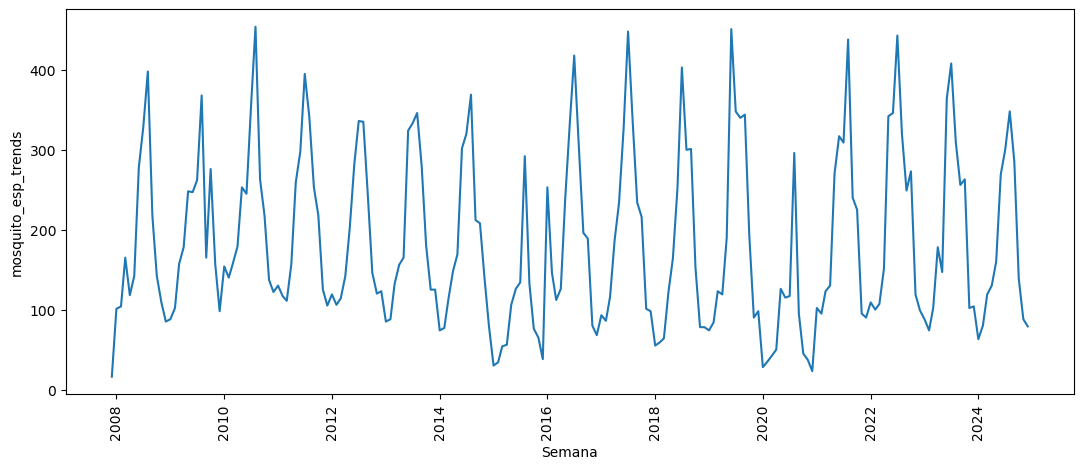

In [7]:
#Visualización de datos mensuales
plt.figure(figsize=(13,5))
sns.lineplot(data=data,x=data.index,y=data.mosquito_esp_trends)
plt.xticks(rotation=90)
plt.show()

In [8]:
#Exportamos los datos relativos a las búsquedas de mosquito en España
data.to_csv('mosquito_esp_trends.csv',index=True,encoding='utf-8')